# Random Forest — SDY1737 (single institution)

**Per-study notebook in the federated architecture.**

This notebook fits a Random Forest on **SDY1737 alone** to predict
log(C-peptide AUC). A random forest is a non-linear model — an ensemble of
decision trees — so unlike Ridge or LASSO it has **no coefficient vector**.
The shareable summary is the **feature-importance vector** (how much each
feature reduced impurity across the trees), written to CSV for inspection.

The forest itself is SDY1737's contribution to the **Union-of-Forests**: in
the federated notebook, every institution keeps its own forest, and a new
subject is predicted by **every** forest with the predictions averaged. No
trees and no subject rows ever move between institutions.

- **Input:** SDY1737's Panel A and Panel B.
- **Output:** `vectors/SDY1737_rf_panelA_importance.csv` and `vectors/SDY1737_rf_panelB_importance.csv`.


## Why Random Forest

Ridge and LASSO are linear: they fit a weight per feature. A random forest
instead splits the data on feature thresholds and can capture **interactions
and non-linear effects** the linear models cannot. The cost is that there is
no single coefficient to share — the model is the trees themselves. For
federation, the trees are combined as a Union-of-Forests (averaging
predictions), and feature importance is the interpretable summary each
institution can publish.


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

import oadr_data as od

RNG_SEED = 42
N_TREES = 200
np.random.seed(RNG_SEED)
(REPO / "vectors").mkdir(exist_ok=True)
(REPO / "figures").mkdir(exist_ok=True)
print("Repo root:", REPO)


Repo root: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody


## 2. Load SDY1737 only

Same panels as the Ridge and LASSO notebooks. Panel A (9 features) and Panel B (12 features).


In [2]:
PANEL_A_FEATS = ['MIAA', 'GAD65', 'IA2IC', 'ICA', 'ZNT8', '8-12', '13-17', '>18', 'Sex']
a = od.load_panel_a("SDY1737")
Xa = a[PANEL_A_FEATS].values.astype(float)
ya = a[od.PANEL_A_TARGET].values.astype(float)
print(f"Panel A: N={len(ya)}, features={len(PANEL_A_FEATS)}")

PANEL_B_FEATS = ['Sex', 'age_years', 'disease_duration_years', 'bmi', 'height_cm', 'weight_kg', 'GAD65', 'IA2IC', 'MIAA', 'ZNT8', 'ICA', 'received_active_treatment']
b_raw = od.load_panel_b("SDY1737")
for col in ("bmi", "height_cm", "weight_kg"):
    b_raw[col] = b_raw[col].fillna(b_raw[col].median())
bad_h = b_raw["height_cm"] <= 0
b_raw.loc[bad_h, "height_cm"] = np.sqrt(b_raw.loc[bad_h, "weight_kg"] / b_raw.loc[bad_h, "bmi"]) * 100
Xb_full, yb, _ = od.panel_b_design_matrix(b_raw)
Xb = Xb_full.reindex(columns=PANEL_B_FEATS).values.astype(float)
yb = yb.values.astype(float)
print(f"Panel B: N={len(yb)}, features={len(PANEL_B_FEATS)}")


Panel A: N=16, features=9
Panel B: N=16, features=12


## 3. Fit the forest and write the SDY1737 importance vector

A `RandomForestRegressor` (200 trees) is fit on all of SDY1737's rows.
Trees are scale-invariant, but we still apply a per-study `MinMaxScaler` so the
federated inference step is identical across methods. The per-feature impurity
decrease (importance) is written to `vectors/`.


In [3]:
def fit_and_save(X, y, feats, panel_label):
    sc = MinMaxScaler().fit(X)
    rf = RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=2,
                               n_jobs=1, random_state=RNG_SEED).fit(sc.transform(X), y)
    vec = pd.DataFrame({"feature": feats, "importance": rf.feature_importances_})
    vec["n_subjects"] = len(y)
    vec["study"] = "SDY1737"
    vec["panel"] = panel_label
    path = f"vectors/{"SDY1737"}_rf_panel{panel_label}_importance.csv"
    vec.to_csv(path, index=False)
    top = vec.sort_values("importance", ascending=False).head(3)["feature"].tolist()
    print(f"Wrote {path}  (top features: {top})")
    return vec


In [4]:
vec_a = fit_and_save(Xa, ya, PANEL_A_FEATS, "A")
print()
print("Panel A feature importances:")
print(vec_a[["feature", "importance"]].sort_values("importance", ascending=False).to_string(index=False))

vec_b = fit_and_save(Xb, yb, PANEL_B_FEATS, "B")
print()
print("Panel B feature importances:")
print(vec_b[["feature", "importance"]].sort_values("importance", ascending=False).to_string(index=False))


Wrote vectors/SDY1737_rf_panelA_importance.csv  (top features: ['GAD65', 'ZNT8', 'MIAA'])

Panel A feature importances:
feature  importance
  GAD65    0.364564
   ZNT8    0.211196
   MIAA    0.160038
  IA2IC    0.131173
    >18    0.048022
  13-17    0.038826
   8-12    0.029792
    Sex    0.016390
    ICA    0.000000
Wrote vectors/SDY1737_rf_panelB_importance.csv  (top features: ['GAD65', 'weight_kg', 'bmi'])

Panel B feature importances:
                  feature  importance
                    GAD65    0.219649
                weight_kg    0.140375
                      bmi    0.134840
                     ZNT8    0.112010
                     MIAA    0.097492
                age_years    0.096513
   disease_duration_years    0.091134
                    IA2IC    0.064535
                height_cm    0.038483
                      Sex    0.004969
                      ICA    0.000000
received_active_treatment    0.000000


## 4. SDY1737 importance graphic

The forest's feature importances as a horizontal bar chart (sorted). Tall bars
are the features SDY1737's forest relied on most. Panel A (left) and Panel B (right).


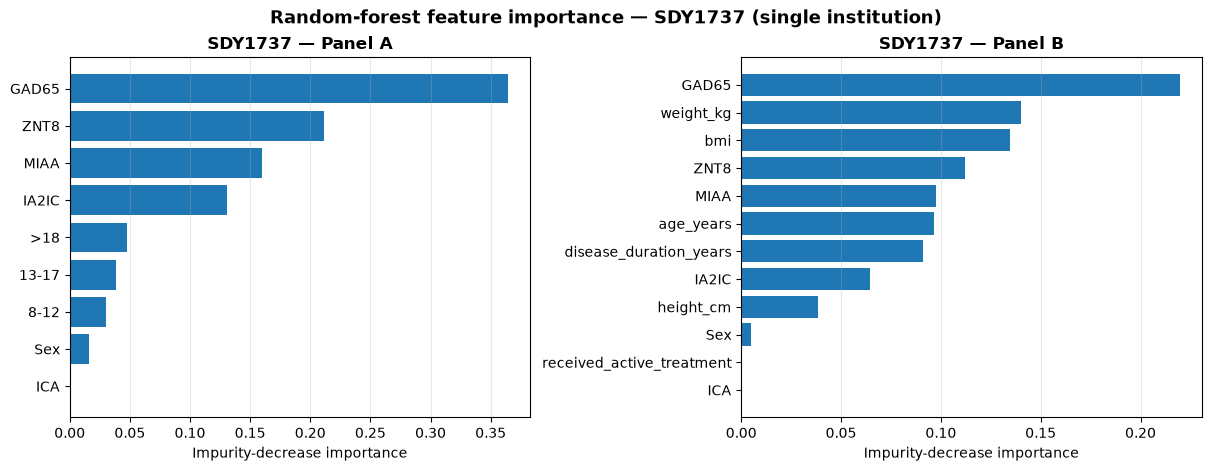

In [5]:
def plot_imp(ax, vec, title):
    d = vec.sort_values("importance", ascending=True)
    ax.barh(d.feature, d.importance, color="#1f77b4")
    ax.set_xlabel("Impurity-decrease importance")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

panels = ["A", "B"]
vecs = {"A": vec_a, "B": vec_b}
fig, axes = plt.subplots(1, len(panels), figsize=(6.0 * len(panels), 4.6),
                         constrained_layout=True, squeeze=False)
for ax, p in zip(axes[0], panels):
    plot_imp(ax, vecs[p], f"SDY1737 — Panel {p}")
fig.suptitle("Random-forest feature importance — SDY1737 (single institution)",
             fontsize=13, fontweight="bold")
fig.savefig("figures/rf_importance_SDY1737.pdf", dpi=300)
fig.savefig("figures/rf_importance_SDY1737.png", dpi=220)
plt.show()


## 5. Solo performance (within-study cross-validation)

What SDY1737's forest achieves **on its own**. 5-fold CV within SDY1737 (fewer
folds if N is small); the forest is fit on each training fold and predicts the
held-out fold. This is the baseline the Union-of-Forests will be compared
against.


In [6]:
def solo_cv(X, y, n_splits=5, seed=RNG_SEED):
    n_splits = max(2, min(n_splits, len(y) // 2))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    preds = np.full_like(y, np.nan, dtype=float)
    for tr, te in kf.split(X):
        sc = MinMaxScaler().fit(X[tr])
        rf = RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=2,
                                   n_jobs=1, random_state=seed).fit(sc.transform(X[tr]), y[tr])
        preds[te] = rf.predict(sc.transform(X[te]))
    mask = ~np.isnan(preds)
    mse = mean_squared_error(y[mask], preds[mask])
    rss = np.sum((y[mask] - preds[mask]) ** 2)
    tss = np.sum((y[mask] - y[mask].mean()) ** 2)
    r2 = 1 - rss / tss if tss > 0 else float("nan")
    return mse, r2, n_splits

mse_a, r2_a, k_a = solo_cv(Xa, ya)
print(f"Panel A solo {k_a}-fold CV:  MSE={mse_a:.3f}  R²={r2_a:+.3f}")
if Xb is not None:
    mse_b, r2_b, k_b = solo_cv(Xb, yb)
    print(f"Panel B solo {k_b}-fold CV:  MSE={mse_b:.3f}  R²={r2_b:+.3f}")


Panel A solo 5-fold CV:  MSE=0.575  R²=-0.559
Panel B solo 5-fold CV:  MSE=0.540  R²=-0.463


## 6. Federation from SDY1737's view — borrowing the other institutions' forests

A forest has no coefficient vector, so the federation is a Union-of-Forests:
SDY1737 keeps its own forest, and the other institutions send their forests.
On the four features LASSO selected (weight_kg, GAD65, received_active_treatment,
Sex), SDY1737 does its own 5-fold cross-validation. **Solo**: its held-out
subjects are predicted by its own forest. **Federated**: the same subjects are
predicted by every forest (its own and the others'), averaged. No subject-level
data moves — only the trained forests.


In [7]:
SEL = ["weight_kg", "GAD65", "received_active_treatment", "Sex"]
FED_PARTNERS = ["SDY524", "SDY569"]    # extended-panel cohort excluding SDY1737
THIS = "SDY1737"

def load4(s):
    b = od.load_panel_b(s)
    for c in ("bmi", "height_cm", "weight_kg"):
        b[c] = b[c].fillna(b[c].median())
    bad = b["height_cm"] <= 0
    b.loc[bad, "height_cm"] = np.sqrt(b.loc[bad, "weight_kg"] / b.loc[bad, "bmi"]) * 100
    X, y, _ = od.panel_b_design_matrix(b)
    return X.reindex(columns=SEL).values.astype(float), y.values.astype(float)

# Other institutions' forests (each fit on its own four-feature data)
partners = [s for s in FED_PARTNERS if s != THIS]
partner_forests = []
for s in partners:
    Xo, yo = load4(s)
    sc = MinMaxScaler().fit(Xo)
    fo = RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=2,
                               n_jobs=1, random_state=RNG_SEED).fit(sc.transform(Xo), yo)
    partner_forests.append((fo, sc))

X4, y4 = load4(THIS)
kf = KFold(min(5, max(2, len(y4) // 2)), shuffle=True, random_state=RNG_SEED)
solo = np.full(len(y4), np.nan)
fed = np.full(len(y4), np.nan)
for tr, te in kf.split(X4):
    sc = MinMaxScaler().fit(X4[tr])
    f = RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=2,
                              n_jobs=1, random_state=RNG_SEED).fit(sc.transform(X4[tr]), y4[tr])
    solo[te] = f.predict(sc.transform(X4[te]))
    preds = [f.predict(sc.transform(X4[te]))]
    for fo, sco in partner_forests:
        preds.append(fo.predict(sco.transform(X4[te])))
    fed[te] = np.mean(preds, axis=0)

def _r2(y, p):
    rss = np.sum((y - p) ** 2); tss = np.sum((y - y.mean()) ** 2)
    return 1 - rss / tss if tss > 0 else float("nan")

r2_solo = _r2(y4, solo); r2_fed = _r2(y4, fed)
print(f"{THIS} borrowing forests from {partners}:")
print(f"  solo      R2 = {r2_solo:+.3f}")
print(f"  federated R2 = {r2_fed:+.3f}")


SDY1737 borrowing forests from ['SDY524', 'SDY569']:
  solo      R2 = -0.205
  federated R2 = -0.160


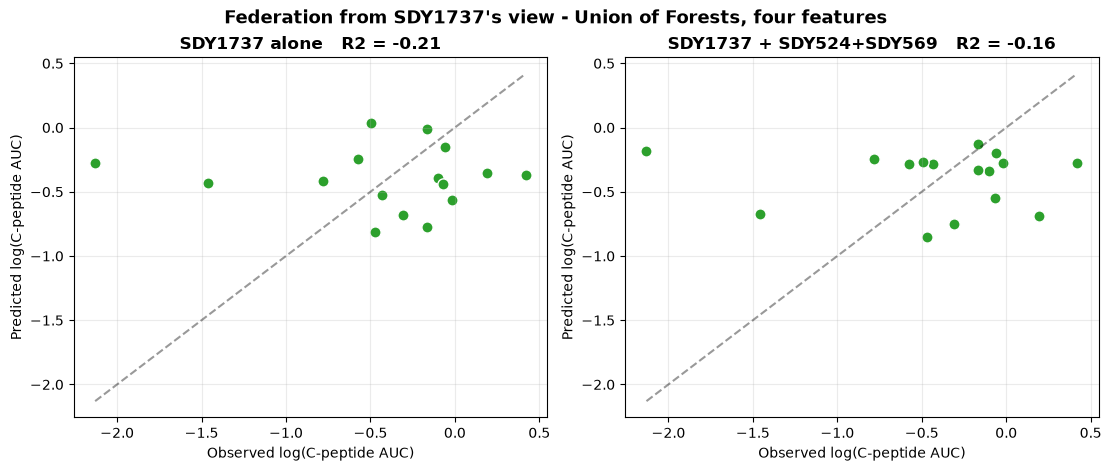

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
lo = min(y4.min(), np.nanmin(solo), np.nanmin(fed))
hi = max(y4.max(), np.nanmax(solo), np.nanmax(fed))
for ax, pred, title, r2v in [(axes[0], solo, THIS + " alone", r2_solo),
                             (axes[1], fed, THIS + " + " + "+".join(partners), r2_fed)]:
    ax.scatter(y4, pred, c="#2ca02c", s=65, edgecolor="white")
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    ax.set_xlabel("Observed log(C-peptide AUC)")
    ax.set_ylabel("Predicted log(C-peptide AUC)")
    ax.set_title(f"{title}   R2 = {r2v:+.2f}", fontweight="bold")
    ax.grid(alpha=0.25)
fig.suptitle("Federation from " + THIS + "'s view - Union of Forests, four features",
             fontsize=13, fontweight="bold")
fig.savefig("figures/federation_view_rf_" + THIS + ".pdf", dpi=300)
fig.savefig("figures/federation_view_rf_" + THIS + ".png", dpi=220)
plt.show()


## 7. Outputs

Importance vectors written to `vectors/`:

- `SDY1737_rf_panelA_importance.csv`
- `SDY1737_rf_panelB_importance.csv`

Figure: `figures/rf_importance_SDY1737.pdf` / `.png`

Next: the **federated Random Forest** notebook combines the institutions'
forests as a Union-of-Forests (each forest predicts, predictions averaged) and
shows the additive-benefit cohort curves.
